Δv₁ = 2371.63 m/s, Δv₂ = 1446.99 m/s, ToF = 5.31 hr


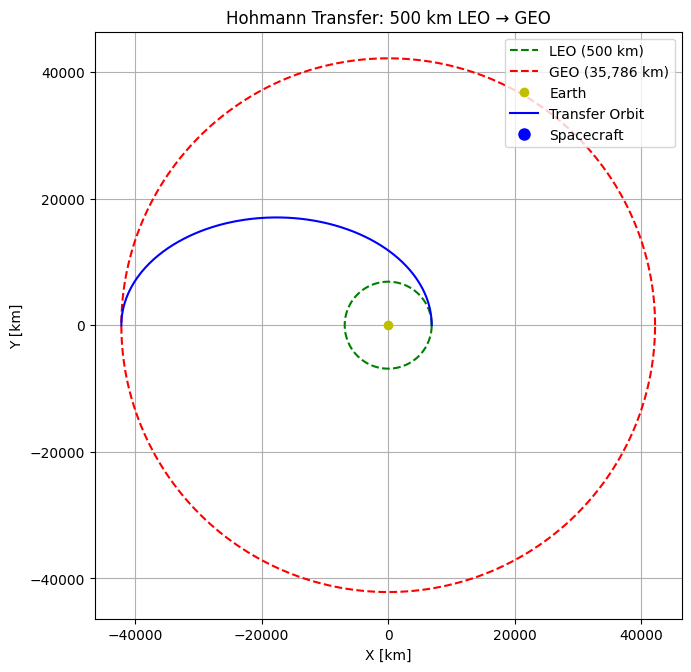

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- Constants ---
mu_earth = 3.986e14        # Earth's gravitational parameter [m^3/s^2]
r_earth = 6371e3           # Earth's radius [m]
r_leo = r_earth + 500e3    # Low Earth Orbit (500 km altitude)
r_geo = r_earth + 35786e3  # Geostationary Orbit (35,786 km altitude)

# --- Orbital parameters ---
a_transfer = (r_leo + r_geo) / 2
v_leo = np.sqrt(mu_earth / r_leo)
v_geo = np.sqrt(mu_earth / r_geo)
v_perigee = np.sqrt(mu_earth * (2 / r_leo - 1 / a_transfer))
v_apogee = np.sqrt(mu_earth * (2 / r_geo - 1 / a_transfer))

delta_v1 = v_perigee - v_leo
delta_v2 = v_geo - v_apogee
tof = np.pi * np.sqrt(a_transfer**3 / mu_earth)  # Time of flight for half orbit

print(f"Δv₁ = {delta_v1:.2f} m/s, Δv₂ = {delta_v2:.2f} m/s, ToF = {tof/3600:.2f} hr")

# --- Orbit coordinates ---
theta = np.linspace(0, 2 * np.pi, 500)
x_leo = r_leo * np.cos(theta)
y_leo = r_leo * np.sin(theta)
x_geo = r_geo * np.cos(theta)
y_geo = r_geo * np.sin(theta)

# --- Transfer orbit (from perigee at theta=0 to apogee at theta=pi) ---
theta_transfer = np.linspace(0, np.pi, 300)
e_transfer = (r_geo - r_leo) / (r_geo + r_leo)
r_transfer = a_transfer * (1 - e_transfer**2) / (1 + e_transfer * np.cos(theta_transfer))
x_transfer = r_transfer * np.cos(theta_transfer)
y_transfer = r_transfer * np.sin(theta_transfer)

# --- Velocity along the transfer orbit (instantaneous speed) ---
v_transfer = np.sqrt(mu_earth * (2 / r_transfer - 1 / a_transfer))  # [m/s]

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlabel("X [km]")
ax.set_ylabel("Y [km]")
ax.set_aspect('equal', 'box')
ax.grid(True)

# Plot orbits
ax.plot(x_leo / 1000, y_leo / 1000, 'g--', label='LEO (500 km)')
ax.plot(x_geo / 1000, y_geo / 1000, 'r--', label='GEO (35,786 km)')
ax.plot(0, 0, 'yo', label='Earth')
ax.plot(x_transfer / 1000, y_transfer / 1000, 'b-', label='Transfer Orbit')

(spacecraft_line,) = ax.plot([], [], 'bo', markersize=8, label='Spacecraft')
# Text artist to show current velocity (in axes coordinates)
velocity_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, va='top', fontsize=10)

ax.legend(loc='upper right')

# --- Animation functions ---
def init():
    spacecraft_line.set_data([], [])
    velocity_text.set_text('')
    return spacecraft_line, velocity_text

def update(frame):
    # spacecraft position
    spacecraft_line.set_data([x_transfer[frame] / 1000], [y_transfer[frame] / 1000])
    # instantaneous velocity in km/s
    current_v_kms = v_transfer[frame] / 1000.0
    velocity_text.set_text(f"Speed = {current_v_kms:.3f} km/s")
    return spacecraft_line, velocity_text

# --- Animate ---
ani = FuncAnimation(
    fig,
    update,
    frames=len(x_transfer),
    init_func=init,
    blit=True,        # we return the artists so blitting works
    interval=30,
    repeat=False
)

plt.title("Hohmann Transfer: 500 km LEO → GEO")
plt.tight_layout()
plt.show()